Slope: -0.851 ± 0.009
Lens Power: 3.33 ± 0.02 Diopters


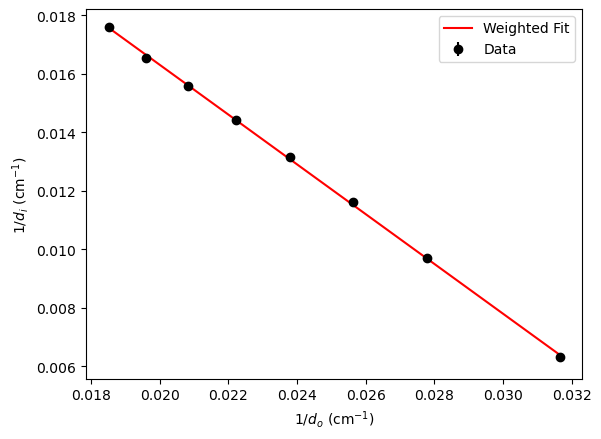

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Data
do = np.array([37.6, 42.0, 45.0, 48.0, 51.0, 54.0, 57.0, 60.0])-6.0
ddo = 0.2 # cm

di = np.array([190.0-do[0], 139.0 -do[1], 125.0-do[2], 118.0-do[3], 114.3-do[4], 112.2-do[5], 111.5-do[6], 110.8-do[7]])
ddi = np.array([4.0, 1.0 , 1.0, 0.6, 0.5, 0.2, 0.2, 0.1])

# Transform to linear space (Units: 1/cm)
x = 1/do
y = 1/di

# Note: Since do errors are very small, 
# we focus on di errors for the weights
sigma_y = ddi / (di**2)
weights = 1 / sigma_y

# Weighted Polyfit (degree 1 for a line)
# cov=True allows us to get the uncertainty of the fit parameters
params, cov = np.polyfit(x, y, 1, w=weights, cov=True)

m, b = params
dm, db = np.sqrt(np.diag(cov))

# Power is the intercept 'b' in units of 1/cm. 
# Convert to Diopters (1/m) by multiplying by 100.
power_diopters = b * 100
power_error = db * 100

print(f"Slope: {m:.3f} ± {dm:.3f}")
print(f"Lens Power: {power_diopters:.2f} ± {power_error:.2f} Diopters")

# Plotting
plt.errorbar(x, y, yerr=sigma_y, fmt='ko', label='Data')
plt.plot(x, m*x + b, 'r-', label='Weighted Fit')
plt.xlabel('$1/d_o$ (cm$^{-1}$)')
plt.ylabel('$1/d_i$ (cm$^{-1}$)')
plt.legend()
plt.show()

In [12]:
print(di)

[158.4 103.   86.   76.   69.3  64.2  60.5  56.8]
